# Ridge, Lasso Regression

In [1]:
#California Housing Dataset: Load the california housing dataset.

from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [2]:
#Creating feature and target arrays
X, y = housing.data, housing.target
columns = housing.feature_names

# The original code had X=X[y<50] and y=y[y<50], which was specific to the Boston dataset.
# This filtering is removed as it might not be appropriate for the California Housing dataset.

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.3,
                                                    random_state=42)

## RIDGE REGRESSION

The first type of regularized regression that we'll look at is called ridge regression
in which our loss function is the standard OLS function plus the squared value of each coefficient
multipled by some constant alpha

$\min_{w} || X w - y||_2^2 + \alpha ||w||_2^2$

When minimizing the loss function to fit to our data, models are penalized for
coefficients with a large magnitude: large positive and large negative coefficients

NOTE that alpha is a parameter that we need to choose in order to fit and predict
essentially, we can select the alpha for which our model performs best (hyper parameter tuning)

alpha controls model complexity
Notice that when alpha=0 we get back OLS (large coeff no penalized - overfitting problem is not accounted for)
Very high alpha can lead to underfitting the data (model too simple)
alpha controls regularization strength; must be a positive float.

Regularization improves the conditioning of the problem and reduces the variance of the estimates.
Larger values specify stronger regularization.

In [11]:
#DEFINE YOUR REGRESSOR and THE PARAMETERS GRID
from sklearn.linear_model import Ridge
import numpy as np

regressor = Ridge()

parameters = {"alpha": [0.001,0.01,0.1,1,10]}
#note that we set alpha using the argument alpha
#also notice the argument normalize: setting this equal to True ensures that all
#our variables are on the same scale

#DEFINE YOUR GRIDSEARCH
from sklearn.model_selection import GridSearchCV
gs = GridSearchCV(regressor, parameters, cv=3) #with no params it reduces to a CV

gs = gs.fit(X_train,y_train)

#summarize the results of your GRIDSEARCH
print('***GRIDSEARCH RESULTS***')
print("Best score: %f using %s" % (gs.best_score_, gs.best_params_))
means = gs.cv_results_['mean_test_score']
stds = gs.cv_results_['std_test_score']
params = gs.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

#test on hold-out
gs.score(X_test, y_test)

***GRIDSEARCH RESULTS***
Best score: 0.607524 using {'alpha': 1}
0.607522 (0.009368) with: {'alpha': 0.001}
0.607522 (0.009368) with: {'alpha': 0.01}
0.607523 (0.009366) with: {'alpha': 0.1}
0.607524 (0.009344) with: {'alpha': 1}
0.607517 (0.009144) with: {'alpha': 10}


0.5958178603951636

In [7]:
#Independent term in the linear model.
print('Intercept: ', gs.best_estimator_.intercept_)

import pandas as pd
pd.DataFrame(list(zip(columns,gs.best_estimator_.coef_)), columns = ['features','estimatedCoefficients'])

Intercept:  -37.05181677486492


,features,estimatedCoefficients
0,MedInc,4.456403e-01
1,HouseAge,9.683907e-03
2,AveRooms,-1.217486e-01
3,AveBedrms,7.766705e-01
4,Population,-7.704474e-07
5,AveOccup,-3.369492e-03
6,Latitude,-4.185296e-01
7,Longitude,-4.336561e-01


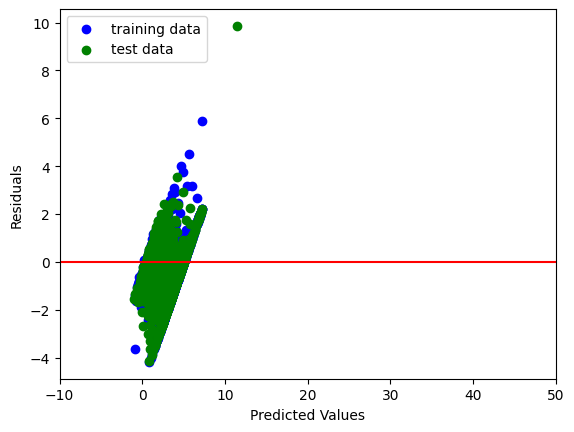

In [8]:
error_train=gs.predict(X_train)-y_train
error_test=gs.predict(X_test)-y_test

%matplotlib inline
import matplotlib.pyplot as plt

plt.scatter(gs.predict(X_train),error_train, c="b", label="training data")
plt.scatter(gs.predict(X_test),error_test, c="g", label="test data")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.legend(loc="upper left")
plt.hlines(y=0, xmin=-10, xmax=50, color="r")
plt.xlim([-10,50])
plt.show()

In [9]:
from sklearn import metrics

print("MAE train: ", metrics.mean_absolute_error(y_train, gs.predict(X_train)))
print("MSE train: ",metrics.mean_squared_error(y_train, gs.predict(X_train)))
print("RMSE train: ",np.sqrt(metrics.mean_squared_error(y_train, gs.predict(X_train))))
print("r2: ",np.sqrt(metrics.r2_score(y_train, gs.predict(X_train))))

print("MAE test: ", metrics.mean_absolute_error(y_test, gs.predict(X_test)))
print("MSE test: ",metrics.mean_squared_error(y_test, gs.predict(X_test)))
print("RMSE test: ",np.sqrt(metrics.mean_squared_error(y_test, gs.predict(X_test))))
print("r2: ",np.sqrt(metrics.r2_score(y_test, gs.predict(X_test))))

MAE train:  0.5309810015477319
MSE train:  0.5233577422311327
RMSE train:  0.7234346841499464
r2:  0.7806061030685663
MAE test:  0.5272556668172419
MSE test:  0.5305052690933699
RMSE test:  0.7283579264986205
r2:  0.7718923891289274


## Lasso Regression

Lasso used the L1 penalty to regularize, while ridge used the L2 penalty.

$ \min_{w} ||X w - y||_2 ^ 2 + \alpha ||w||_1 $

In [12]:

#DEFINE YOUR REGRESSOR and THE PARAMETERS GRID
from sklearn.linear_model import Lasso
import numpy as np

regressor = Lasso()
parameters = {"alpha": [0.001,0.01,0.1,1,10]}

#DEFINE YOUR GRIDSEARCH
from sklearn.model_selection import GridSearchCV
gs = GridSearchCV(regressor, parameters, cv=3) #with no params it reduces to a CV

gs = gs.fit(X_train,y_train)

lasso_coef = gs.best_estimator_.coef_
print(lasso_coef)

#summarize the results of your GRIDSEARCH
print('***GRIDSEARCH RESULTS***')
print("Best score: %f using %s" % (gs.best_score_, gs.best_params_))
means = gs.cv_results_['mean_test_score']
stds = gs.cv_results_['std_test_score']
params = gs.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

#test on hold-out
gs.score(X_test, y_test)

[ 4.41930348e-01  9.74218323e-03 -1.14609874e-01  7.37324328e-01
 -5.81572034e-07 -3.35392890e-03 -4.17269746e-01 -4.31811665e-01]
***GRIDSEARCH RESULTS***
Best score: 0.607498 using {'alpha': 0.001}
0.607498 (0.009033) with: {'alpha': 0.001}
0.603477 (0.006291) with: {'alpha': 0.01}
0.545928 (0.005619) with: {'alpha': 0.1}
0.288076 (0.000837) with: {'alpha': 1}
0.000446 (0.000184) with: {'alpha': 10}


0.5966991029178376

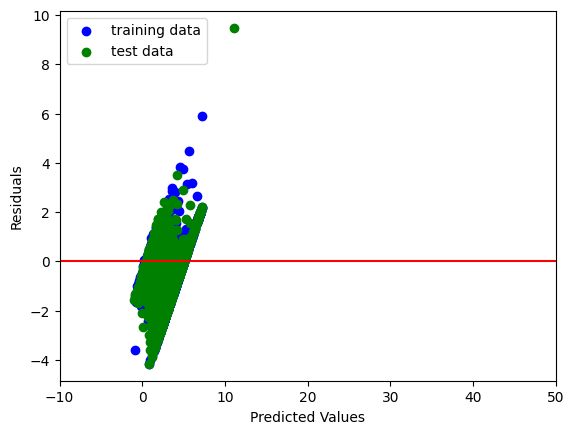

In [13]:
error_train=gs.predict(X_train)-y_train
error_test=gs.predict(X_test)-y_test

plt.scatter(gs.predict(X_train),error_train, c="b", label="training data")
plt.scatter(gs.predict(X_test),error_test, c="g", label="test data")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.legend(loc="upper left")
plt.hlines(y=0, xmin=-10, xmax=50, color="r")
plt.xlim([-10,50])
plt.show()

In [14]:
from sklearn import metrics

print("MAE train: ", metrics.mean_absolute_error(y_train, gs.predict(X_train)))
print("MSE train: ",metrics.mean_squared_error(y_train, gs.predict(X_train)))
print("RMSE train: ",np.sqrt(metrics.mean_squared_error(y_train, gs.predict(X_train))))
print("r2: ",np.sqrt(metrics.r2_score(y_train, gs.predict(X_train))))

print("MAE test: ", metrics.mean_absolute_error(y_test, gs.predict(X_test)))
print("MSE test: ",metrics.mean_squared_error(y_test, gs.predict(X_test)))
print("RMSE test: ",np.sqrt(metrics.mean_squared_error(y_test, gs.predict(X_test))))
print("r2: ",np.sqrt(metrics.r2_score(y_test, gs.predict(X_test))))

MAE train:  0.5312225105640692
MSE train:  0.5234133721922059
RMSE train:  0.7234731316311656
r2:  0.7805795051309186
MAE test:  0.5274233435790637
MSE test:  0.5293486029376493
RMSE test:  0.7275634700406896
r2:  0.7724630107117347
